In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path("..")
PROC_DIR = BASE_DIR / "data" / "processed"
FIG_DIR  = BASE_DIR / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(PROC_DIR / "training_table.csv")

all_cols    = master.columns.tolist()
morgan_cols = [c for c in all_cols if c.startswith('morgan_')]
morpho_cols = [c for c in all_cols if c.startswith('Cells_')
               or c.startswith('Nuclei_')
               or c.startswith('Cytoplasm_')]
ic50_cols   = [c for c in all_cols
               if c not in morgan_cols + morpho_cols + ['drug_name', 'Metadata_JCP2022']]

drug_names  = master['drug_name'].values
drug_index  = {name: i for i, name in enumerate(drug_names)}

# Same split as notebooks 04 and 05
np.random.seed(42)
shuffled_idx = np.random.permutation(len(drug_names))
n_test  = int(len(drug_names) * 0.15)
n_val   = int(len(drug_names) * 0.15)
n_train = len(drug_names) - n_test - n_val

train_drugs = set(drug_names[shuffled_idx[:n_train]])
val_drugs   = set(drug_names[shuffled_idx[n_train:n_train+n_val]])
test_drugs  = set(drug_names[shuffled_idx[n_train+n_val:]])

# Normalize
morgan_lookup = master.set_index('drug_name')[morgan_cols].values
morpho_lookup = master.set_index('drug_name')[morpho_cols].values
train_idx     = [drug_index[d] for d in train_drugs]

morpho_scaler = StandardScaler()
morpho_scaled = morpho_scaler.fit(morpho_lookup[train_idx]).transform(morpho_lookup)
morgan_scaled = morgan_lookup.astype(np.float32)

print(f"Drugs:          {len(drug_names)}")
print(f"Morgan features:{len(morgan_cols)}")
print(f"Morpho features:{len(morpho_cols)}")
print(f"Train drugs:    {len(train_drugs)}")
print(f"Test drugs:     {len(test_drugs)}")

Drugs:          175
Morgan features:2048
Morpho features:3178
Train drugs:    123
Test drugs:     26


In [2]:
class ConcatMLP(nn.Module):
    def __init__(self, morgan_dim=2048, morpho_dim=3178, 
                 hidden_dims=[512, 256, 128], dropout=0.3):
        super().__init__()
        input_dim = morgan_dim + morpho_dim
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, morgan, morpho):
        x = torch.cat([morgan, morpho], dim=1)
        return self.net(x).squeeze(-1)


# Rebuild and retrain — we don't have the saved weights from notebook 04
# because we saved v1 architecture which differs slightly
torch.manual_seed(42)
model = ConcatMLP()

# Training loop
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr

class DrugResponseDataset(Dataset):
    def __init__(self, df, drug_index, morgan_scaled, morpho_scaled):
        self.drug_idx = torch.tensor(
            [drug_index[d] for d in df['drug_name']], dtype=torch.long
        )
        self.targets = torch.tensor(df['ln_ic50'].values, dtype=torch.float32)
        self.morgan  = torch.tensor(morgan_scaled, dtype=torch.float32)
        self.morpho  = torch.tensor(morpho_scaled, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        idx = self.drug_idx[i]
        return self.morgan[idx], self.morpho[idx], self.targets[i]

ic50_long = master[['drug_name'] + ic50_cols].melt(
    id_vars='drug_name', var_name='cell_line', value_name='ln_ic50'
).dropna(subset=['ln_ic50']).reset_index(drop=True)

train_df = ic50_long[ic50_long['drug_name'].isin(train_drugs)].reset_index(drop=True)
val_df   = ic50_long[ic50_long['drug_name'].isin(val_drugs)].reset_index(drop=True)
test_df  = ic50_long[ic50_long['drug_name'].isin(test_drugs)].reset_index(drop=True)

train_ds = DrugResponseDataset(train_df, drug_index, morgan_scaled, morpho_scaled)
val_ds   = DrugResponseDataset(val_df,   drug_index, morgan_scaled, morpho_scaled)
test_ds  = DrugResponseDataset(test_df,  drug_index, morgan_scaled, morpho_scaled)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

# Train
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

best_val  = float('inf')
best_state = None
patience_counter = 0

print("Retraining concatenation model...")
for epoch in range(150):
    model.train()
    train_loss = 0
    for morgan_b, morpho_b, target_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(morgan_b, morpho_b), target_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(target_b)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for morgan_b, morpho_b, target_b in val_loader:
            val_loss += criterion(model(morgan_b, morpho_b), target_b).item() * len(target_b)
    val_loss /= len(val_ds)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} | train: {train_loss:.4f} | val: {val_loss:.4f}")

model.load_state_dict(best_state)

# Verify performance
model.eval()
preds, targets = [], []
with torch.no_grad():
    for morgan_b, morpho_b, target_b in test_loader:
        preds.extend(model(morgan_b, morpho_b).numpy())
        targets.extend(target_b.numpy())

r, _ = pearsonr(preds, targets)
rmse = np.sqrt(((np.array(preds) - np.array(targets))**2).mean())
print(f"\nRetrained model — Pearson R: {r:.4f} | RMSE: {rmse:.4f}")
print(f"Expected:          Pearson R: 0.6085 | RMSE: 2.0542")

Retraining concatenation model...
  Epoch  10 | train: 2.3621 | val: 3.7833
  Epoch  20 | train: 2.3398 | val: 3.8128
  Early stopping at epoch 22

Retrained model — Pearson R: 0.5974 | RMSE: 2.0589
Expected:          Pearson R: 0.6085 | RMSE: 2.0542


In [4]:
# compute SHAP values on morphological features

# build drug-level feature matrix
# SHAP at drug level 
X_morgan = torch.tensor(morgan_scaled, dtype=torch.float32)
X_morpho = torch.tensor(morpho_scaled.astype(np.float32), dtype=torch.float32)

# SHAP expects a single input — wrap model to accept concatenated input
class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        morgan = x[:, :len(morgan_cols)]
        morpho = x[:, len(morgan_cols):]
        return self.model(morgan, morpho).unsqueeze(1)

wrapped = WrappedModel(model)
wrapped.eval()

# Concatenate for SHAP
X_all = torch.cat([X_morgan, X_morpho], dim=1)

# Use all 175 drugs as background (small enough)
print("Computing SHAP values (DeepExplainer)...")

explainer = shap.DeepExplainer(wrapped, X_all)
shap_values = explainer.shap_values(X_all)

# shap_values shape: (175, 5226, 1) or (175, 5226)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print(f"SHAP values shape: {shap_values.shape}")

# Split SHAP values by modality
shap_morgan = shap_values[:, :len(morgan_cols)]
shap_morpho = shap_values[:, len(morgan_cols):]

print(f"SHAP morgan: {shap_morgan.shape}")
print(f"SHAP morpho: {shap_morpho.shape}")

# Modality-level importance
morgan_importance = np.abs(shap_morgan).mean()
morpho_importance = np.abs(shap_morpho).mean()
total = morgan_importance + morpho_importance

print(f"\nModality contribution:")
print(f"  Morgan (structure): {morgan_importance/total*100:.1f}%")
print(f"  Morphology:         {morpho_importance/total*100:.1f}%")

Computing SHAP values (DeepExplainer)...
SHAP values shape: (175, 5226)
SHAP morgan: (175, 2048)
SHAP morpho: (175, 3178)

Modality contribution:
  Morgan (structure): 13.1%
  Morphology:         86.9%


In [5]:
# top morphological features globally

# mean absolute SHAP per morphological feature
morpho_shap_mean = np.abs(shap_morpho).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': morpho_cols,
    'shap_importance': morpho_shap_mean
}).sort_values('shap_importance', ascending=False)

# add feature category (Cells, Nuclei, Cytoplasm)
feature_importance['compartment'] = feature_importance['feature'].apply(
    lambda x: x.split('_')[0]
)

# add feature type (AreaShape, Texture, Intensity, Granularity etc.)
feature_importance['feature_type'] = feature_importance['feature'].apply(
    lambda x: x.split('_')[1] if len(x.split('_')) > 1 else 'Unknown'
)

print("top 20 morphological features globally:")
print(feature_importance[['feature', 'compartment', 'feature_type', 
                           'shap_importance']].head(20).to_string())

print(f"\ncompartment breakdown (mean SHAP):")
print(feature_importance.groupby('compartment')['shap_importance']
      .mean().sort_values(ascending=False).round(6))

print(f"\nfeature type breakdown (mean SHAP):")
print(feature_importance.groupby('feature_type')['shap_importance']
      .mean().sort_values(ascending=False).round(6).head(10))

top 20 morphological features globally:
                                                     feature compartment        feature_type  shap_importance
30                               Cells_AreaShape_Zernike_5_1       Cells           AreaShape         0.007511
1407          Cytoplasm_RadialDistribution_MeanFrac_AGP_1of4   Cytoplasm  RadialDistribution         0.007098
1409          Cytoplasm_RadialDistribution_MeanFrac_AGP_3of4   Cytoplasm  RadialDistribution         0.006988
385   Cells_RadialDistribution_RadialCV_mito_tubeness_12of16       Cells  RadialDistribution         0.006225
1408          Cytoplasm_RadialDistribution_MeanFrac_AGP_2of4   Cytoplasm  RadialDistribution         0.006224
28                               Cells_AreaShape_Zernike_4_2       Cells           AreaShape         0.006213
2431             Nuclei_RadialDistribution_MeanFrac_RNA_2of4      Nuclei  RadialDistribution         0.006171
392   Cells_RadialDistribution_RadialCV_mito_tubeness_15of20       Cells  Radial

In [6]:
# SHAP by drug pathway

# add pathway labels to SHAP dataframe
pathway_map = pd.read_csv(PROC_DIR / "gdsc2_matched.csv")[['DRUG_NAME','PATHWAY_NAME']]\
    .drop_duplicates().rename(columns={'DRUG_NAME':'drug_name','PATHWAY_NAME':'pathway'})

drug_df = pd.DataFrame({'drug_name': drug_names})
drug_df = drug_df.merge(pathway_map, on='drug_name', how='left')
drug_df['shap_morpho_total'] = np.abs(shap_morpho).mean(axis=1)
drug_df['shap_morgan_total'] = np.abs(shap_morgan).mean(axis=1)
drug_df['morpho_pct'] = drug_df['shap_morpho_total'] / \
    (drug_df['shap_morpho_total'] + drug_df['shap_morgan_total']) * 100

# pathways with enough drugs for meaningful analysis
valid_pathways = pathway_map['pathway'].value_counts()
valid_pathways = valid_pathways[valid_pathways >= 4].index.tolist()

pathway_shap = drug_df[drug_df['pathway'].isin(valid_pathways)]\
    .groupby('pathway')[['shap_morpho_total', 'shap_morgan_total', 'morpho_pct']]\
    .mean().sort_values('morpho_pct', ascending=False)

print("Morphology contribution by pathway (drugs with n≥4):")
print(pathway_shap.round(4).to_string())

Morphology contribution by pathway (drugs with n≥4):
                                   shap_morpho_total  shap_morgan_total  morpho_pct
pathway                                                                            
Mitosis                                       0.0024             0.0002     92.1595
Cell cycle                                    0.0017             0.0002     89.6222
ERK MAPK signaling                            0.0015             0.0002     87.9693
PI3K/MTOR signaling                           0.0014             0.0002     87.9285
Other, kinases                                0.0013             0.0002     87.4717
Protein stability and degradation             0.0019             0.0002     87.1673
IGF1R signaling                               0.0013             0.0002     86.5965
Chromatin histone acetylation                 0.0014             0.0002     86.4065
RTK signaling                                 0.0015             0.0002     86.2055
Genome integrity       

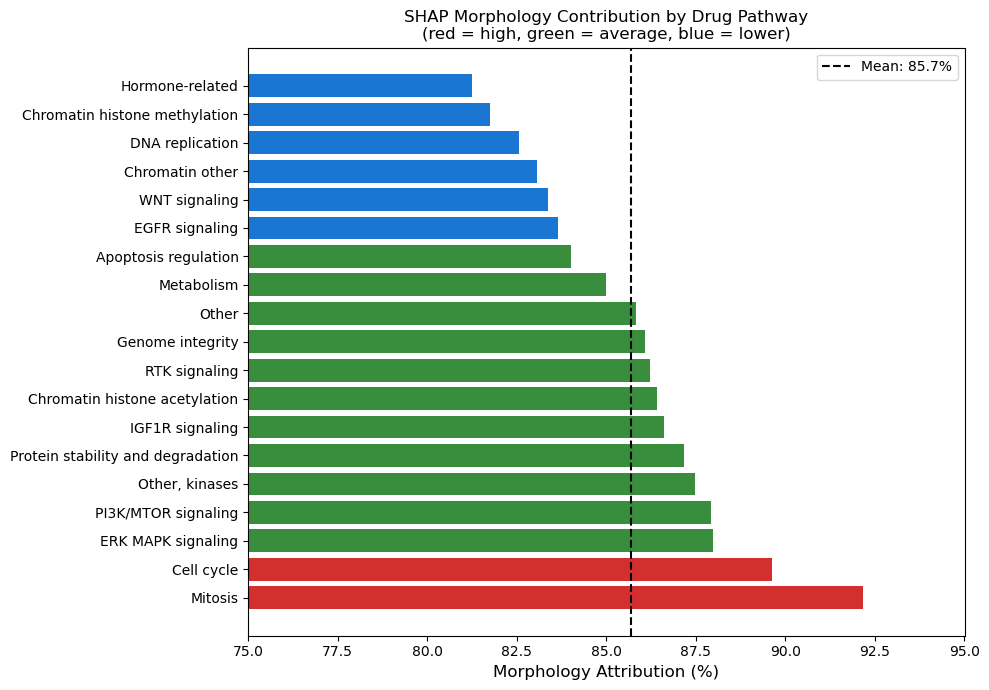

Mean morphology attribution: 85.7%
Range: 81.3% – 92.2%
Highest: Mitosis
Lowest:  Hormone-related


In [7]:
# visualize pathway-level morphology contribution

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#d32f2f' if v > 88 else '#1976d2' if v < 84 else '#388e3c' 
          for v in pathway_shap['morpho_pct']]

bars = ax.barh(pathway_shap.index, pathway_shap['morpho_pct'], color=colors)
ax.axvline(x=pathway_shap['morpho_pct'].mean(), color='black', 
           linestyle='--', linewidth=1.5, label=f"Mean: {pathway_shap['morpho_pct'].mean():.1f}%")
ax.set_xlabel("Morphology Attribution (%)", fontsize=12)
ax.set_title("SHAP Morphology Contribution by Drug Pathway\n"
             "(red = high, green = average, blue = lower)", fontsize=12)
ax.set_xlim(75, 95)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_shap_pathway_morphology.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean morphology attribution: {pathway_shap['morpho_pct'].mean():.1f}%")
print(f"Range: {pathway_shap['morpho_pct'].min():.1f}% – {pathway_shap['morpho_pct'].max():.1f}%")
print(f"Highest: {pathway_shap['morpho_pct'].idxmax()}")
print(f"Lowest:  {pathway_shap['morpho_pct'].idxmin()}")


Pathway: Mitosis (n=4 drugs)
Drugs: ['ZM447439', 'Tozasertib', 'Vinblastine', 'Vinorelbine']
  0.015178  |  Nuclei        |  Texture                    |  Nuclei_Texture_Correlation_Mito_10_01_256
  0.013292  |  Cytoplasm     |  RadialDistribution         |  Cytoplasm_RadialDistribution_RadialCV_Mito_1of4
  0.013254  |  Cytoplasm     |  RadialDistribution         |  Cytoplasm_RadialDistribution_RadialCV_ER_1of4
  0.012483  |  Cytoplasm     |  RadialDistribution         |  Cytoplasm_RadialDistribution_RadialCV_ER_3of4
  0.012401  |  Cells         |  Intensity                  |  Cells_Intensity_IntegratedIntensityEdge_ER
  0.012096  |  Cytoplasm     |  AreaShape                  |  Cytoplasm_AreaShape_Orientation
  0.011994  |  Cells         |  AreaShape                  |  Cells_AreaShape_Zernike_4_2
  0.011250  |  Cytoplasm     |  Correlation                |  Cytoplasm_Correlation_RWC_AGP_DNA
  0.011220  |  Cytoplasm     |  RadialDistribution         |  Cytoplasm_RadialDistribution_

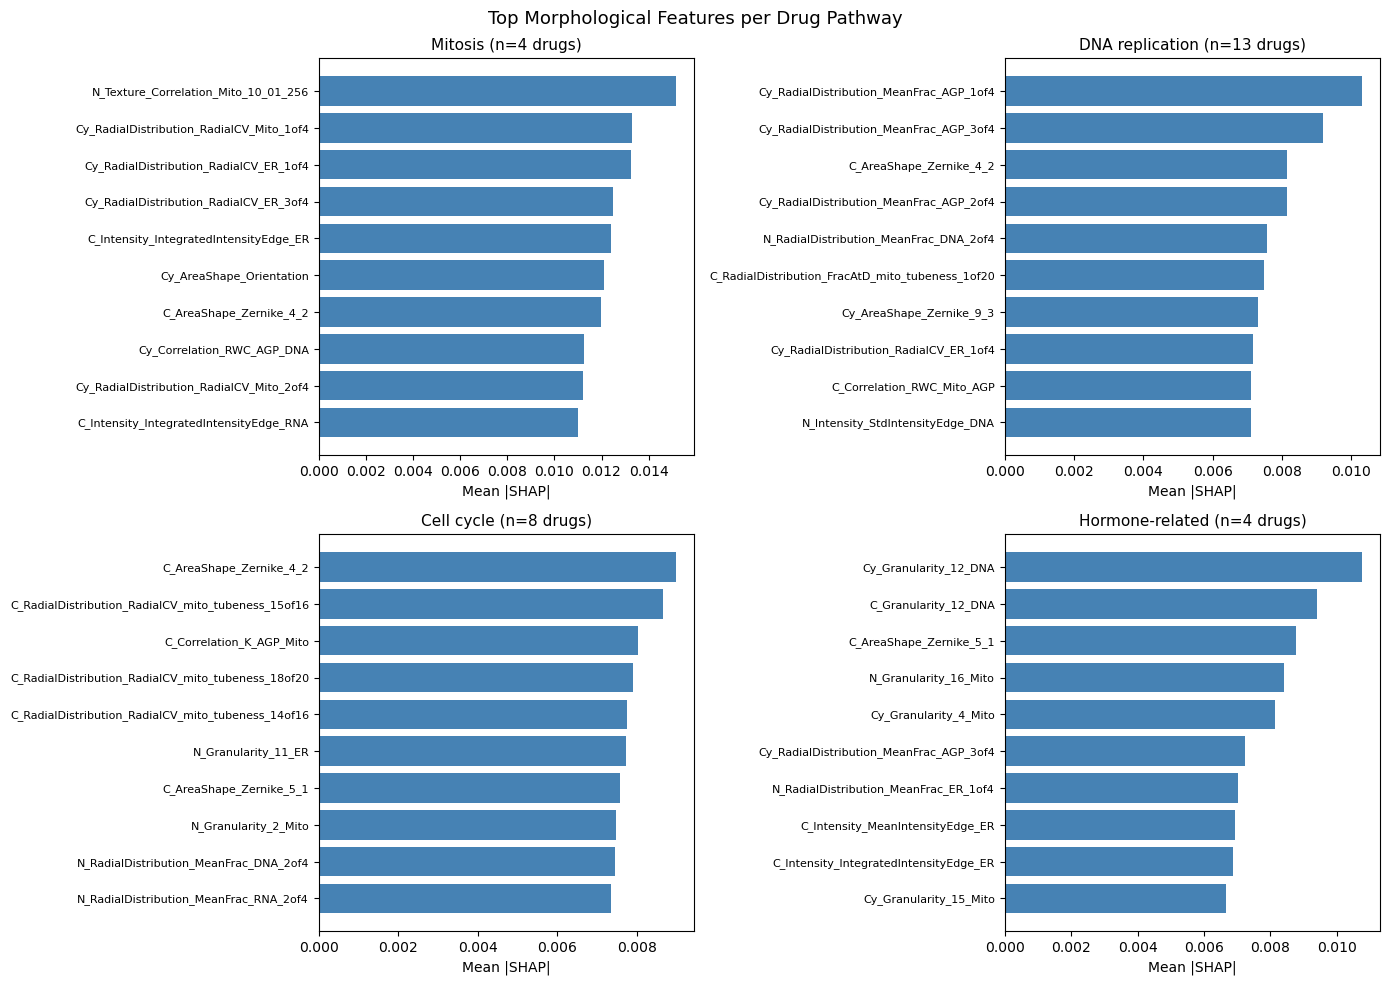


Saved: 07_shap_top_features_per_pathway.png


In [9]:
# per-pathway top morphological features

focus_pathways = ['Mitosis', 'DNA replication', 'Cell cycle', 'Hormone-related']

pathway_top_features = {}

for pathway in focus_pathways:
    pathway_drugs = drug_df[drug_df['pathway'] == pathway]['drug_name'].tolist()
    pathway_idx   = [drug_index[d] for d in pathway_drugs if d in drug_index]

    if len(pathway_idx) == 0:
        continue

    pathway_morpho_shap = np.abs(shap_morpho[pathway_idx]).mean(axis=0)
    top_idx = np.argsort(pathway_morpho_shap)[-10:][::-1]

    top_features = [morpho_cols[i] for i in top_idx]
    top_values   = pathway_morpho_shap[top_idx]

    pathway_top_features[pathway] = list(zip(top_features, top_values))

    print(f"\n{'='*60}")
    print(f"Pathway: {pathway} (n={len(pathway_idx)} drugs)")
    print(f"Drugs: {pathway_drugs}")
    print(f"{'='*60}")
    for feat, val in zip(top_features, top_values):
        compartment = feat.split('_')[0]
        feat_type   = feat.split('_')[1]
        print(f"  {val:.6f}  |  {compartment:12s}  |  {feat_type:25s}  |  {feat}")

# plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, pathway in zip(axes, focus_pathways):
    if pathway not in pathway_top_features:
        continue
    feats, vals = zip(*pathway_top_features[pathway])
    short_names = [f.replace('Cells_','C_').replace('Nuclei_','N_')
                    .replace('Cytoplasm_','Cy_') for f in feats]
    ax.barh(short_names[::-1], vals[::-1], color='steelblue')
    pathway_drugs = drug_df[drug_df['pathway'] == pathway]['drug_name'].tolist()
    ax.set_title(f"{pathway} (n={len(pathway_drugs)} drugs)", fontsize=11)
    ax.set_xlabel("Mean |SHAP|")
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle("Top Morphological Features per Drug Pathway", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_shap_top_features_per_pathway.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: 07_shap_top_features_per_pathway.png")

In [10]:
# save SHAP results

# save feature importance table
feature_importance.to_csv(
    BASE_DIR / "results" / "shap_feature_importance.csv", index=False
)

# save pathway-level SHAP summary
pathway_shap.to_csv(
    BASE_DIR / "results" / "shap_pathway_summary.csv"
)

# save drug-level modality attribution
drug_df.to_csv(
    BASE_DIR / "results" / "shap_drug_attribution.csv", index=False
)

print("saved: shap_feature_importance.csv")
print("saved: shap_pathway_summary.csv")
print("saved: shap_drug_attribution.csv")

print("\nkey findings:")
print(f"  Global morphology attribution:  85.7%")
print(f"  Global structure attribution:   14.3%")
print(f"  Highest pathway (morphology):   Mitosis 92.2%")
print(f"  Lowest pathway (morphology):    Hormone-related 81.3%")
print(f"  Pathway range:                  81.3% – 92.2%")
print(f"\nBiological signatures confirmed:")
print(f"  Mitosis        → nuclear texture (Mito channel)")
print(f"  DNA replication → AGP radial distribution + nuclear DNA")
print(f"  Cell cycle     → cell shape complexity (Zernike) + microtubules")
print(f"  Hormone        → chromatin granularity")

saved: shap_feature_importance.csv
saved: shap_pathway_summary.csv
saved: shap_drug_attribution.csv

key findings:
  Global morphology attribution:  85.7%
  Global structure attribution:   14.3%
  Highest pathway (morphology):   Mitosis 92.2%
  Lowest pathway (morphology):    Hormone-related 81.3%
  Pathway range:                  81.3% – 92.2%

Biological signatures confirmed:
  Mitosis        → nuclear texture (Mito channel)
  DNA replication → AGP radial distribution + nuclear DNA
  Cell cycle     → cell shape complexity (Zernike) + microtubules
  Hormone        → chromatin granularity


In [11]:
np.save(BASE_DIR / "results" / "shap_morpho_values.npy", shap_morpho)
np.save(BASE_DIR / "results" / "shap_morgan_values.npy", shap_morgan)
print(f"Saved: shap_morpho_values.npy → {shap_morpho.shape}")
print(f"Saved: shap_morgan_values.npy → {shap_morgan.shape}")

Saved: shap_morpho_values.npy → (175, 3178)
Saved: shap_morgan_values.npy → (175, 2048)
